# Isekai vs Cultivation — Machine Learning

**Three models:**
1. **Regression** — Predict cultivation novel rating from tags, genre, year, chapters
2. **Classification** — Predict whether a novel will be high or low rated
3. **Clustering** — Find natural archetypes in the novel dataset

Each model connects directly to EDA findings.

## 1. Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.pipeline import Pipeline
from matplotlib.patches import Patch
import joblib

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

NOVEL_COLOR  = '#DD8452'
ANIME_COLOR  = '#4C72B0'
ACCENT_COLOR = '#55A868'
BAD_COLOR    = '#C44E52'

DB_PATH = 'isekai_vs_cultivation.db'
conn = sqlite3.connect(DB_PATH)
print('Connected:', DB_PATH)

Connected: isekai_vs_cultivation.db


## 2. Feature Engineering

In [2]:
novels_raw = pd.read_sql_query('SELECT * FROM novels', conn)
novels_raw['year']               = pd.to_numeric(novels_raw['year'], errors='coerce')
novels_raw['rating']             = pd.to_numeric(novels_raw['rating'], errors='coerce')
novels_raw['num_chapters']       = pd.to_numeric(novels_raw['num_chapters'], errors='coerce')
novels_raw['reading_list_count'] = pd.to_numeric(novels_raw['reading_list_count'], errors='coerce')
novels_raw['vote_count']         = pd.to_numeric(novels_raw['vote_count'], errors='coerce')

novels = novels_raw[novels_raw['vote_count'] >= 5].copy()

novel_tags_df   = pd.read_sql_query('SELECT nt.novel_id, t.name AS tag FROM novel_tags nt JOIN tags t ON nt.tag_id = t.id', conn)
novel_genres_df = pd.read_sql_query('SELECT ng.novel_id, g.name AS genre FROM novel_genres ng JOIN genres g ON ng.genre_id = g.id', conn)

rated_ids = set(novels['id'].tolist())
novel_tags_rated   = novel_tags_df[novel_tags_df['novel_id'].isin(rated_ids)]
novel_genres_rated = novel_genres_df[novel_genres_df['novel_id'].isin(rated_ids)]

print(f'Rated novels: {len(novels):,}')

Rated novels: 2,936


In [3]:
TOP_N_TAGS   = 40
TOP_N_GENRES = 10

top_tags   = novel_tags_rated['tag'].value_counts().head(TOP_N_TAGS).index.tolist()
top_genres = novel_genres_rated['genre'].value_counts().head(TOP_N_GENRES).index.tolist()

tag_pivot = novel_tags_rated[novel_tags_rated['tag'].isin(top_tags)].copy()
tag_pivot['value'] = 1
tag_matrix = tag_pivot.pivot_table(
    index='novel_id', columns='tag', values='value', aggfunc='max', fill_value=0
).reset_index()
tag_matrix.columns = ['novel_id'] + [f'tag_{c}' for c in tag_matrix.columns[1:]]

genre_pivot = novel_genres_rated[novel_genres_rated['genre'].isin(top_genres)].copy()
genre_pivot['value'] = 1
genre_matrix = genre_pivot.pivot_table(
    index='novel_id', columns='genre', values='value', aggfunc='max', fill_value=0
).reset_index()
genre_matrix.columns = ['novel_id'] + [f'genre_{c}' for c in genre_matrix.columns[1:]]

print(f'Tag features:   {len(top_tags)}')
print(f'Genre features: {len(top_genres)}')

Tag features:   40
Genre features: 10


In [4]:
df = novels[['id', 'rating', 'year', 'num_chapters', 'reading_list_count',
             'vote_count', 'status', 'language', 'completely_translated']].copy()
df = df.rename(columns={'id': 'novel_id'})
df = df.merge(tag_matrix,   on='novel_id', how='left')
df = df.merge(genre_matrix, on='novel_id', how='left')

tag_cols   = [c for c in df.columns if c.startswith('tag_')]
genre_cols = [c for c in df.columns if c.startswith('genre_')]
df[tag_cols + genre_cols] = df[tag_cols + genre_cols].fillna(0)

df['status_enc']     = (df['status'] == 'Completed').astype(int)
df['translated_enc'] = (df['completely_translated'] == 'Yes').astype(int)
df['is_chinese']     = (df['language'] == 'Chinese').astype(int)
df['log_chapters']   = np.log1p(df['num_chapters'].fillna(0))
df['log_readers']    = np.log1p(df['reading_list_count'].fillna(0))
df['log_votes']      = np.log1p(df['vote_count'].fillna(0))
df['year_norm']      = df['year'].fillna(df['year'].median())

FEATURES = (
    ['year_norm', 'log_chapters', 'log_readers', 'log_votes',
     'status_enc', 'translated_enc', 'is_chinese']
    + tag_cols + genre_cols
)

df_model = df.dropna(subset=['rating'])
X = df_model[FEATURES].fillna(0)
y = df_model['rating']

print(f'Feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print(f'Target mean: {y.mean():.3f}, std: {y.std():.3f}')

Feature matrix: 2936 rows x 57 features
Target mean: 3.571, std: 0.545


## 3. Model 1 — Regression (Predict Novel Rating)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 2,348 | Test: 588


In [6]:
lr_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print('Ridge Regression:')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_lr):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}')
print(f'  R2:   {r2_score(y_test, y_pred_lr):.4f}')

Ridge Regression:
  MAE:  0.3279
  RMSE: 0.4291
  R2:   0.3170


In [7]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10,
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print('Random Forest Regression:')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')
print(f'  R2:   {r2_score(y_test, y_pred_rf):.4f}')

cv_scores = cross_val_score(rf_reg, X, y, cv=5, scoring='r2')
print(f'  5-fold CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Random Forest Regression:
  MAE:  0.3252
  RMSE: 0.4270
  R2:   0.3237
  5-fold CV R2: 0.3149 +/- 0.0968


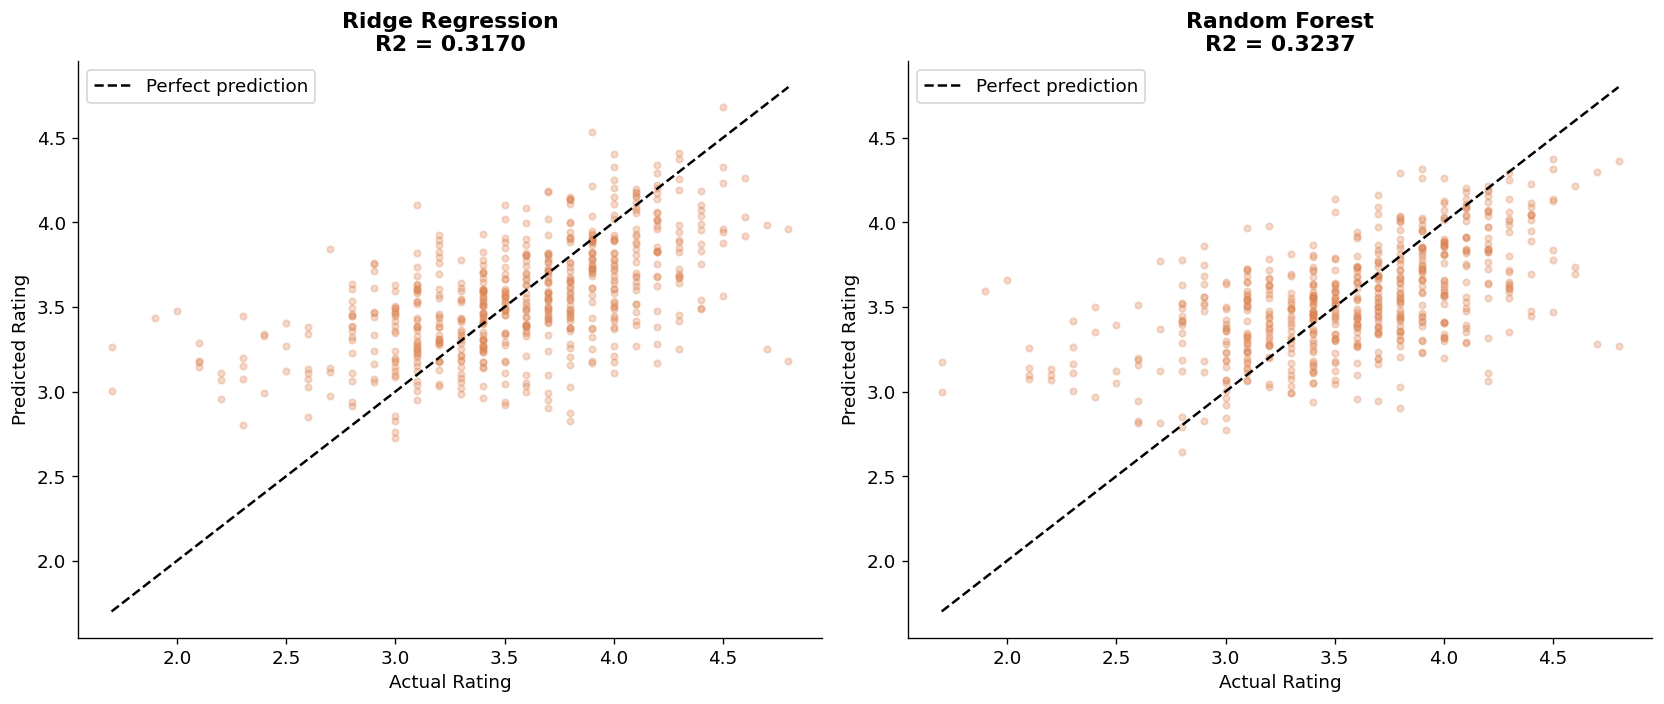

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, title in [
    (axes[0], y_pred_lr, 'Ridge Regression'),
    (axes[1], y_pred_rf, 'Random Forest')
]:
    ax.scatter(y_test, preds, alpha=0.3, s=15, color=NOVEL_COLOR)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Rating')
    ax.set_ylabel('Predicted Rating')
    ax.set_title(f'{title}\nR2 = {r2_score(y_test, preds):.4f}', fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.savefig('ml_01_regression_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

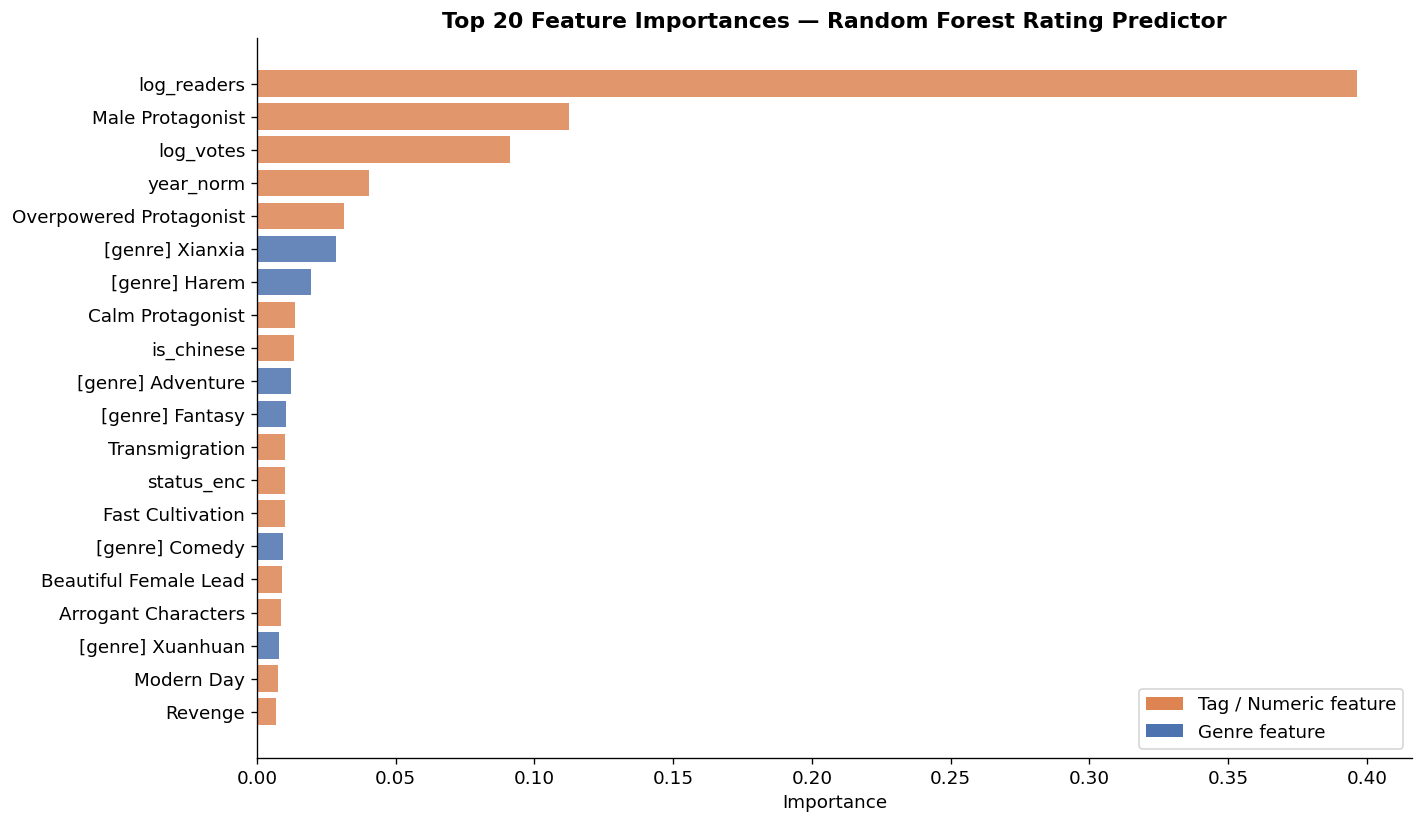


Top 10 most predictive features:
  log_readers                                   0.3966
  tag_Male Protagonist                          0.1126
  log_votes                                     0.0911
  year_norm                                     0.0403
  tag_Overpowered Protagonist                   0.0314
  genre_Xianxia                                 0.0286
  genre_Harem                                   0.0193
  tag_Calm Protagonist                          0.0138
  is_chinese                                    0.0134
  genre_Adventure                               0.0124


In [9]:
importance = pd.Series(rf_reg.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=False).head(20)
clean_names = importance.index.str.replace('tag_', '').str.replace('genre_', '[genre] ')

plt.figure(figsize=(12, 7))
colors = [NOVEL_COLOR if not n.startswith('[genre]') else ANIME_COLOR for n in clean_names]
plt.barh(clean_names[::-1], importance.values[::-1], color=colors[::-1], alpha=0.85)
legend_elements = [Patch(facecolor=NOVEL_COLOR, label='Tag / Numeric feature'),
                   Patch(facecolor=ANIME_COLOR,  label='Genre feature')]
plt.legend(handles=legend_elements, loc='lower right')
plt.title('Top 20 Feature Importances — Random Forest Rating Predictor', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('ml_02_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 most predictive features:')
for feat, imp in importance.head(10).items():
    print(f'  {feat:<45} {imp:.4f}')

## 4. Model 2 — Classification (High vs Low Rating)

In [10]:
HIGH_T = df_model['rating'].quantile(0.75)
LOW_T  = df_model['rating'].quantile(0.25)

clf_mask = (df_model['rating'] >= HIGH_T) | (df_model['rating'] <= LOW_T)
df_clf   = df_model[clf_mask].copy()
df_clf['high_quality'] = (df_clf['rating'] >= HIGH_T).astype(int)

X_clf = df_clf[FEATURES].fillna(0)
y_clf = df_clf['high_quality']

print(f'Dataset: {len(df_clf):,} rows')
print(f'High quality (1): {y_clf.sum():,} ({y_clf.mean()*100:.1f}%)')
print(f'Low quality  (0): {(1-y_clf).sum():,} ({(1-y_clf).mean()*100:.1f}%)')
print(f'Threshold: High >= {HIGH_T:.2f} | Low <= {LOW_T:.2f}')

Dataset: 1,542 rows
High quality (1): 774 (50.2%)
Low quality  (0): 768 (49.8%)
Threshold: High >= 4.00 | Low <= 3.20


In [11]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_clf.fit(X_clf_train, y_clf_train)
y_clf_pred = rf_clf.predict(X_clf_test)

print('Random Forest Classifier:')
print(classification_report(y_clf_test, y_clf_pred,
                             target_names=['Low Quality', 'High Quality']))

cv_clf = cross_val_score(rf_clf, X_clf, y_clf, cv=5, scoring='accuracy')
print(f'5-fold CV Accuracy: {cv_clf.mean():.4f} +/- {cv_clf.std():.4f}')

Random Forest Classifier:
              precision    recall  f1-score   support

 Low Quality       0.77      0.84      0.80       154
High Quality       0.82      0.75      0.79       155

    accuracy                           0.80       309
   macro avg       0.80      0.80      0.80       309
weighted avg       0.80      0.80      0.80       309

5-fold CV Accuracy: 0.7938 +/- 0.0549


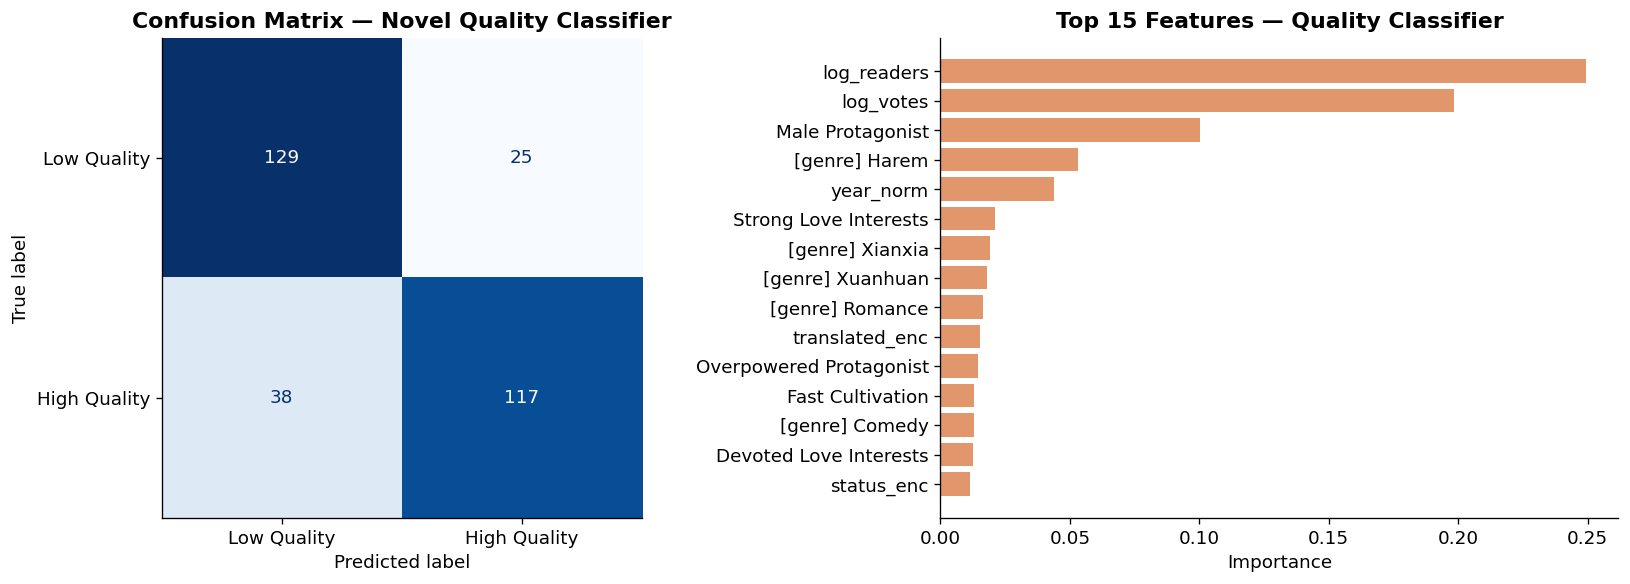

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_clf_test, y_clf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Low Quality', 'High Quality'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Novel Quality Classifier', fontweight='bold')

clf_importance = pd.Series(rf_clf.feature_importances_, index=FEATURES)
clf_importance = clf_importance.sort_values(ascending=False).head(15)
clean = clf_importance.index.str.replace('tag_', '').str.replace('genre_', '[genre] ')
axes[1].barh(clean[::-1], clf_importance.values[::-1], color=NOVEL_COLOR, alpha=0.85)
axes[1].set_title('Top 15 Features — Quality Classifier', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('ml_03_classifier.png', bbox_inches='tight')
plt.show()

## 5. Model 3 — Clustering (Find Archetypes)

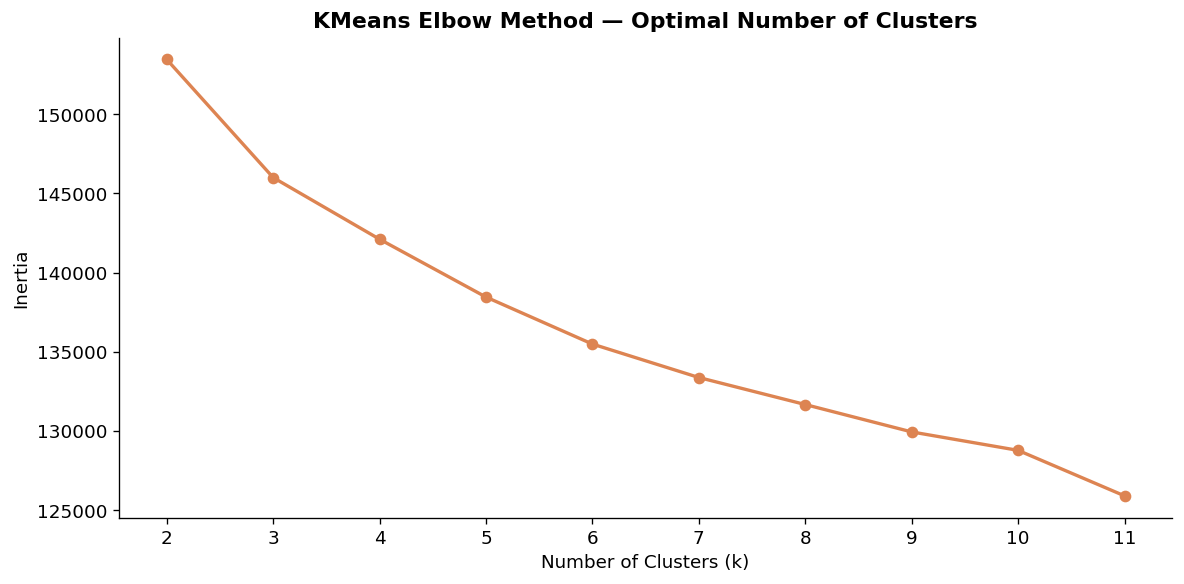

In [13]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))

inertias = []
K_range  = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o', color=NOVEL_COLOR, linewidth=2)
plt.title('KMeans Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('ml_04_elbow.png', bbox_inches='tight')
plt.show()

In [14]:
K = 5

km = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = km.fit_predict(X_scaled)
df_model_cluster = df_model.copy()
df_model_cluster['cluster'] = clusters

cluster_summary = df_model_cluster.groupby('cluster').agg(
    count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    avg_chapters=('num_chapters', 'mean'),
    avg_year=('year', 'mean'),
    avg_readers=('reading_list_count', 'mean')
).round(2)

print(f'Cluster summary (k={K}):')
print(cluster_summary.to_string())

Cluster summary (k=5):
         count  avg_rating  avg_chapters  avg_year  avg_readers
cluster                                                        
0          781        3.61           NaN   2021.56       494.71
1          976        3.35           NaN   2021.43       340.62
2          237        3.31           NaN   2022.48       577.65
3          557        3.97           NaN   2018.83      3687.55
4          385        3.64           NaN   2014.74      4290.19


PCA explained variance: 17.6%


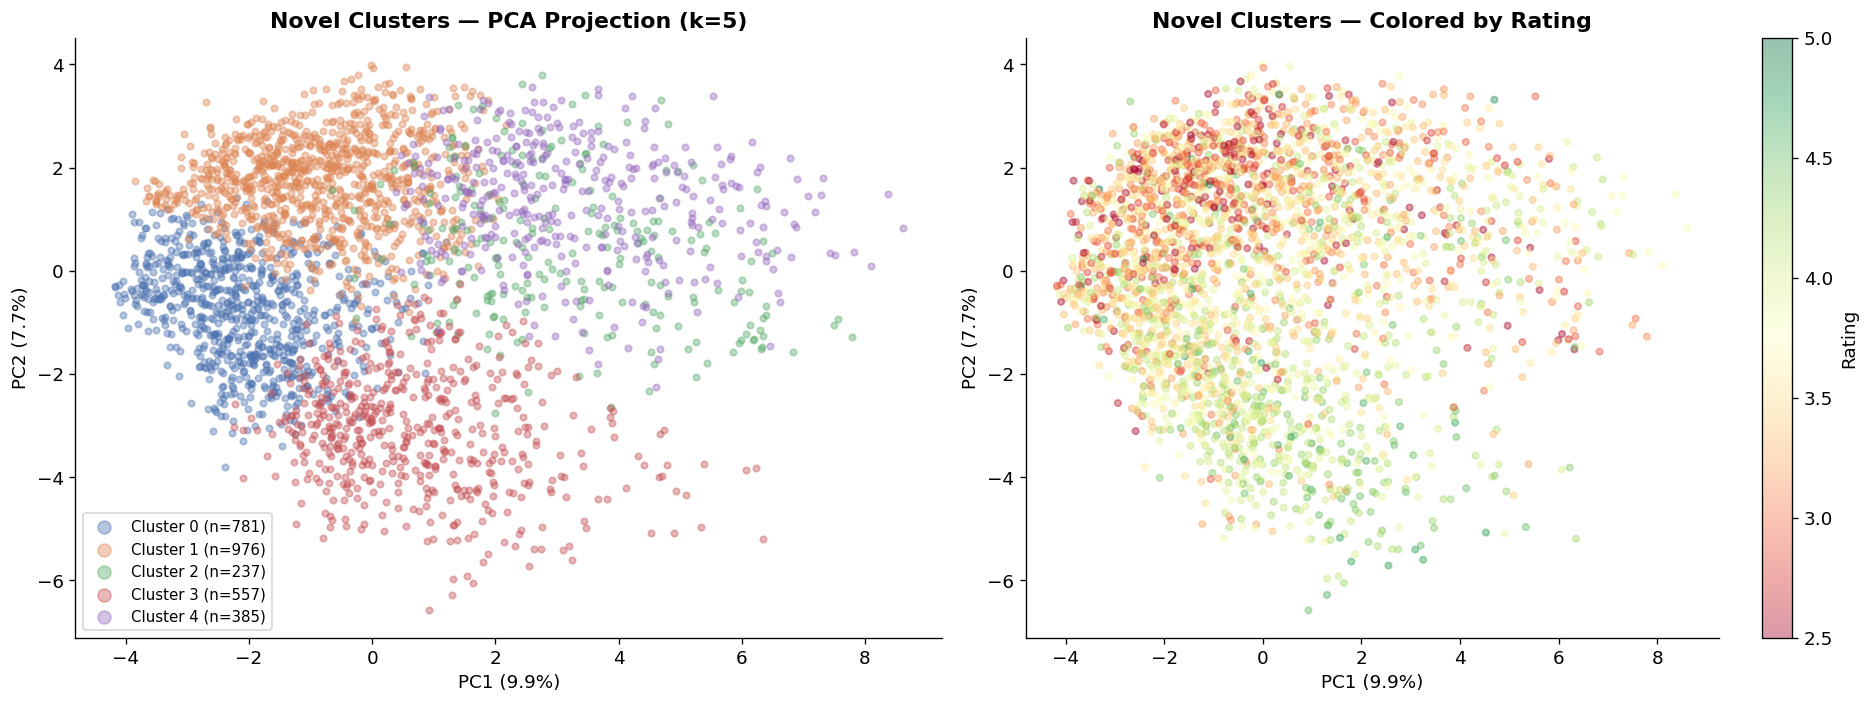

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

colors_cluster = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#9467BD']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i in range(K):
    mask = clusters == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors_cluster[i], alpha=0.4, s=15,
                    label=f'Cluster {i} (n={mask.sum()})')
axes[0].set_title(f'Novel Clusters — PCA Projection (k={K})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(markerscale=2, fontsize=9)

sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df_model['rating'], cmap='RdYlGn',
                     alpha=0.4, s=15, vmin=2.5, vmax=5.0)
plt.colorbar(sc, ax=axes[1], label='Rating')
axes[1].set_title('Novel Clusters — Colored by Rating', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.savefig('ml_05_clusters_pca.png', bbox_inches='tight')
plt.show()

In [16]:
df_model_cluster_tags = df_model_cluster[['novel_id', 'cluster']].merge(
    novel_tags_df, on='novel_id', how='left'
)

print('Top 5 tags per cluster:')
print('=' * 55)
for i in range(K):
    cluster_data = df_model_cluster[df_model_cluster['cluster'] == i]
    cluster_tags = df_model_cluster_tags[df_model_cluster_tags['cluster'] == i]['tag']
    top_5 = cluster_tags.value_counts().head(5)
    avg_r = cluster_data['rating'].mean()
    print(f'\nCluster {i} — avg rating: {avg_r:.2f} | n={len(cluster_data):,}')
    for tag, count in top_5.items():
        print(f'  {tag:<40} {count}')

Top 5 tags per cluster:

Cluster 0 — avg rating: 3.61 | n=781
  Cultivation                              780
  Female Protagonist                       444
  Transmigration                           356
  Beautiful Female Lead                    222
  Handsome Male Lead                       191

Cluster 1 — avg rating: 3.35 | n=976
  Cultivation                              976
  Male Protagonist                         942
  Transmigration                           419
  Weak to Strong                           357
  Overpowered Protagonist                  205

Cluster 2 — avg rating: 3.31 | n=237
  Cultivation                              237
  Male Protagonist                         217
  Fast Cultivation                         173
  Transmigration                           171
  Overpowered Protagonist                  154

Cluster 3 — avg rating: 3.97 | n=557
  Cultivation                              557
  Handsome Male Lead                       425
  Love Interest Falls in 

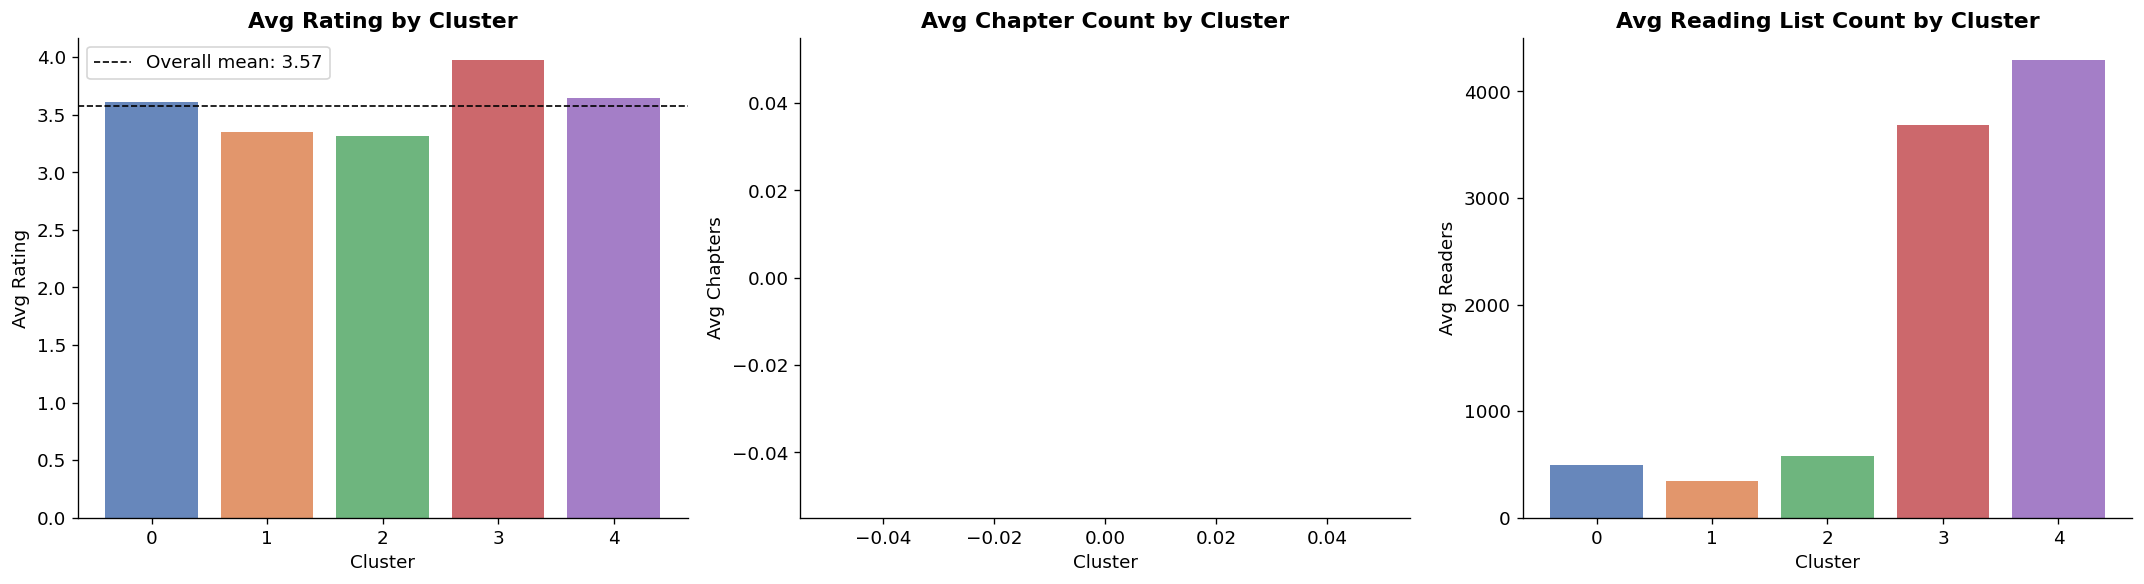

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cluster_summary_plot = cluster_summary.reset_index()

axes[0].bar(cluster_summary_plot['cluster'], cluster_summary_plot['avg_rating'],
            color=[colors_cluster[i] for i in cluster_summary_plot['cluster']], alpha=0.85)
axes[0].axhline(df_model['rating'].mean(), color='black', linestyle='--', linewidth=1,
                label=f'Overall mean: {df_model["rating"].mean():.2f}')
axes[0].set_title('Avg Rating by Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Avg Rating')
axes[0].legend()

axes[1].bar(cluster_summary_plot['cluster'], cluster_summary_plot['avg_chapters'],
            color=[colors_cluster[i] for i in cluster_summary_plot['cluster']], alpha=0.85)
axes[1].set_title('Avg Chapter Count by Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Avg Chapters')

axes[2].bar(cluster_summary_plot['cluster'], cluster_summary_plot['avg_readers'],
            color=[colors_cluster[i] for i in cluster_summary_plot['cluster']], alpha=0.85)
axes[2].set_title('Avg Reading List Count by Cluster', fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Avg Readers')

plt.tight_layout()
plt.savefig('ml_06_cluster_characteristics.png', bbox_inches='tight')
plt.show()

## 6. YoY Growth Rate Correlation (Cross-Dataset)

In [18]:
# Test whether novel and anime YoY growth rates are correlated
anime  = pd.read_sql_query('SELECT * FROM anime', conn)
anime['start_year'] = pd.to_datetime(anime['start_date'], errors='coerce').dt.year
anime['mean']       = pd.to_numeric(anime['mean'], errors='coerce')

novel_by_year = novels.groupby('year').size().reset_index(name='count')
novel_by_year = novel_by_year[(novel_by_year['year'] >= 2010) & (novel_by_year['year'] <= 2025)]
novel_by_year['yoy'] = novel_by_year['count'].pct_change() * 100

anime_by_year = anime.groupby('start_year').size().reset_index(name='count').rename(columns={'start_year': 'year'})
anime_by_year = anime_by_year[(anime_by_year['year'] >= 2010) & (anime_by_year['year'] <= 2025)]
anime_by_year['yoy'] = anime_by_year['count'].pct_change() * 100

merged_yoy = novel_by_year[['year', 'yoy']].merge(
    anime_by_year[['year', 'yoy']], on='year', suffixes=('_novel', '_anime')
).dropna()

corr, pval = stats.pearsonr(merged_yoy['yoy_novel'], merged_yoy['yoy_anime'])
print(f'YoY growth rate correlation:')
print(f'  Pearson r = {corr:.3f}')
print(f'  p-value   = {pval:.4f}')
print(f'  Interpretation: {"weak" if abs(corr) < 0.3 else "moderate" if abs(corr) < 0.6 else "strong"} '      f'{"positive" if corr > 0 else "negative"} correlation')
print(f'  The two genres grow largely independently (low r).')

YoY growth rate correlation:
  Pearson r = 0.279
  p-value   = 0.3141
  Interpretation: weak positive correlation
  The two genres grow largely independently (low r).


## 7. Save Models & Summary

In [19]:
joblib.dump(rf_reg,  'model_rating_regressor.pkl')
joblib.dump(rf_clf,  'model_quality_classifier.pkl')
joblib.dump(km,      'model_kmeans_clusters.pkl')
joblib.dump(scaler,  'model_scaler.pkl')
joblib.dump(FEATURES,'model_features.pkl')
print('Models saved.')

Models saved.


In [20]:
print('=' * 65)
print('ML RESULTS SUMMARY')
print('=' * 65)

print(f'\n[MODEL 1 — Rating Regression]')
print(f'  Algorithm:  Random Forest Regressor (200 trees)')
print(f'  Features:   {len(FEATURES)}')
print(f'  MAE:        {mean_absolute_error(y_test, y_pred_rf):.4f}')
print(f'  RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')
print(f'  R2:         {r2_score(y_test, y_pred_rf):.4f}')
print(f'  CV R2:      {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'  Top feature: {importance.index[0].replace("tag_", "")}')

print(f'\n[MODEL 2 — Quality Classification]')
print(f'  Algorithm:  Random Forest Classifier (200 trees)')
print(f'  Threshold:  High (>={HIGH_T:.1f}) vs Low (<={LOW_T:.1f})')
print(f'  Accuracy:   {accuracy_score(y_clf_test, y_clf_pred):.4f}')
print(f'  CV Accuracy:{cv_clf.mean():.4f} +/- {cv_clf.std():.4f}')

print(f'\n[MODEL 3 — KMeans Clustering]')
print(f'  Algorithm:  KMeans (k={K})')
print(f'  PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')
for i in range(K):
    cd = df_model_cluster[df_model_cluster['cluster'] == i]
    print(f'  Cluster {i}: n={len(cd):,}, avg_rating={cd["rating"].mean():.2f}')

print(f'\n[GROWTH CORRELATION]')
print(f'  Novel-anime YoY growth r = {corr:.3f} (p={pval:.4f})')
print(f'  Low correlation confirms independently driven production cycles')

print('\n' + '=' * 65)
conn.close()
print('Done.')

ML RESULTS SUMMARY

[MODEL 1 — Rating Regression]
  Algorithm:  Random Forest Regressor (200 trees)
  Features:   57
  MAE:        0.3252
  RMSE:       0.4270
  R2:         0.3237
  CV R2:      0.3149 +/- 0.0968
  Top feature: log_readers

[MODEL 2 — Quality Classification]
  Algorithm:  Random Forest Classifier (200 trees)
  Threshold:  High (>=4.0) vs Low (<=3.2)
  Accuracy:   0.7961
  CV Accuracy:0.7938 +/- 0.0549

[MODEL 3 — KMeans Clustering]
  Algorithm:  KMeans (k=5)
  PCA variance explained: 17.6%
  Cluster 0: n=781, avg_rating=3.61
  Cluster 1: n=976, avg_rating=3.35
  Cluster 2: n=237, avg_rating=3.31
  Cluster 3: n=557, avg_rating=3.97
  Cluster 4: n=385, avg_rating=3.64

[GROWTH CORRELATION]
  Novel-anime YoY growth r = 0.279 (p=0.3141)
  Low correlation confirms independently driven production cycles

Done.
